# Proyek Akhir - Eksperimen

Notebook eksperimen untuk sistem ML **Prediksi Pembayaran Tagihan Pajak Daerah** (klasifikasi biner). Disusun oleh **Dwi-Agni**.

## 1. Perkenalan Dataset

Dataset `pajak_daerah_raw.csv` (76.205 baris) berisi catatan tagihan pajak daerah beserta atribut jenis pajak, nominal, temporal, dan wilayah wajib pajak.

- **Target** `label`: `1` = tagihan **dibayar** (lunas), `0` = **belum** dibayar.
- **Fitur numerik**: `total_tax`, `omzet`, `fare`, `period_days`, `deadline_lead_days`, `registration_age_days`, `collection_year`, `collection_month`, `quarter`.
- **Fitur kategorikal**: `tax_code`, `tax_name`, `advertisement_type`, `upt`, `district_name`, `business_name`.
- **Dibuang**: `collection_id` (id), `volume`, `rental_value`, `npa` (mayoritas kosong).

Fitur hanya yang diketahui saat penerbitan tagihan (menghindari kebocoran data / data leakage dari tabel pembayaran).

## 2. Import Library

Impor pustaka analisis data, visualisasi, dan komponen scikit-learn, serta definisikan konstanta kontrak fitur.

In [1]:
# Aktifkan plot inline di Jupyter
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Komponen scikit-learn untuk preprocessing (dipakai di bagian 5)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split

# Tampilan seaborn
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

# ==========================================================================
# KONTRAK FITUR (harus PERSIS sama di semua berkas proyek)
# ==========================================================================
NUMERIC = [
    "total_tax", "omzet", "fare", "period_days", "deadline_lead_days",
    "registration_age_days", "collection_year", "collection_month", "quarter",
]
CATEGORICAL = [
    "tax_code", "tax_name", "advertisement_type", "upt",
    "district_name", "business_name",
]
TARGET = "label"                       # 1 = dibayar/paid, 0 = belum dibayar/unpaid
DROP_COLS = ["collection_id", "volume", "rental_value", "npa"]

print("Library & konstanta kontrak siap.")


Library & konstanta kontrak siap.


## 3. Memuat Data

Muat dataset mentah dan lihat bentuk, cuplikan, struktur, serta ringkasan statistiknya.

In [2]:
# Muat dataset mentah dari direktori yang sama dengan notebook
df = pd.read_csv("pajak_daerah_raw.csv")
print("Bentuk dataset:", df.shape)
df.head()


Bentuk dataset: (76205, 20)


,collection_id,label,tax_code,tax_name,advertisement_type,total_tax,omzet,fare,volume,rental_value,npa,collection_year,collection_month,quarter,period_days,deadline_lead_days,registration_age_days,upt,district_name,business_name
0,46,1,1101,Motel,NaN,1105000.0,11050000.0,10.0,NaN,NaN,NaN,2017,3.0,1.0,27,8,111,f,BENGKAYANG,NaN
1,10,1,1104,Reklame Mini Billboard (ukuran s/d 6m2),1.0,1875000.0,NaN,25.0,NaN,NaN,NaN,2017,6.0,2.0,373,15,132,f,LUAR DAERAH,PT
2,25,1,1111,PAJAK MINRL BKN LGAM & BATUAN,NaN,28350.0,NaN,NaN,NaN,NaN,NaN,2017,6.0,2.0,-276,-97,1,f,SELUAS,NaN
3,27,1,1101,Hotel Melati Satu,NaN,5815000.0,58150000.0,10.0,NaN,NaN,NaN,2017,2.0,1.0,30,5,40,f,BENGKAYANG,CV
4,28,1,1101,Hotel Melati Satu,NaN,7197100.0,71971000.0,10.0,NaN,NaN,NaN,2017,3.0,1.0,27,7,66,f,BENGKAYANG,CV


In [3]:
# Struktur kolom & tipe data
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76205 entries, 0 to 76204
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   collection_id          76205 non-null  int64  
 1   label                  76205 non-null  int64  
 2   tax_code               76205 non-null  int64  
 3   tax_name               76205 non-null  object 
 4   advertisement_type     1193 non-null   float64
 5   total_tax              76205 non-null  float64
 6   omzet                  67103 non-null  float64
 7   fare                   68524 non-null  float64
 8   volume                 0 non-null      float64
 9   rental_value           0 non-null      float64
 10  npa                    120 non-null    float64
 11  collection_year        76205 non-null  int64  
 12  collection_month       76205 non-null  float64
 13  quarter                76205 non-null  float64
 14  period_days            76205 non-null  int64  
 15  de

In [4]:
# Ringkasan statistik kolom numerik
df.describe()


,collection_id,label,tax_code,advertisement_type,total_tax,omzet,fare,volume,rental_value,npa,collection_year,collection_month,quarter,period_days,deadline_lead_days,registration_age_days
count,76205.000000,76205.000000,76205.000000,1193.000000,7.620500e+04,6.710300e+04,68524.000000,0.0,0.0,1.200000e+02,76205.000000,76205.000000,76205.000000,76205.000000,76205.000000,76205.000000
mean,39148.885388,0.417847,1108.700164,1.186085,1.626348e+06,3.506738e+06,3.964954,NaN,NaN,6.301006e+06,2023.312985,7.423214,2.786694,-36.176760,9.222610,476.192231
std,22265.301175,0.493208,4.736132,0.389339,2.548672e+07,3.793644e+07,5.456132,NaN,NaN,4.582120e+06,2.757370,3.445398,1.103091,6368.061601,60.552263,899.705012
min,7.000000,0.000000,1101.000000,1.000000,0.000000e+00,0.000000e+00,0.000000,NaN,NaN,1.101120e+06,2017.000000,1.000000,1.000000,-664729.000000,-1946.000000,-899.000000
25%,20035.000000,0.000000,1102.000000,1.000000,7.760000e+04,0.000000e+00,0.000000,NaN,NaN,2.297700e+06,2022.000000,5.000000,2.000000,8.000000,16.000000,-42.000000
50%,39315.000000,0.000000,1112.000000,1.000000,1.247000e+05,0.000000e+00,0.000000,NaN,NaN,4.618515e+06,2025.000000,8.000000,3.000000,20.000000,25.000000,63.000000
75%,58415.000000,1.000000,1112.000000,1.000000,6.723000e+05,8.250000e+05,10.000000,NaN,NaN,1.096200e+07,2025.000000,10.000000,4.000000,29.000000,34.000000,622.000000
max,77547.000000,1.000000,1113.000000,2.000000,1.176755e+09,5.271501e+09,50.000000,NaN,NaN,1.388181e+07,2026.000000,12.000000,4.000000,760.000000,409.000000,4849.000000


## 4. Exploratory Data Analysis (EDA)

Eksplorasi distribusi target, nilai hilang, sebaran per kategori utama, korelasi antar fitur numerik, dan hubungan nominal pajak dengan status pembayaran.

### 4.1 Distribusi Target
Memeriksa keseimbangan kelas `label`. Ketidakseimbangan kelas perlu diperhatikan saat pemodelan (mis. pemilihan metrik F1/ROC-AUC).

label
0    44363
1    31842
Name: count, dtype: int64

Proporsi:
 label
0    0.582
1    0.418
Name: proportion, dtype: float64


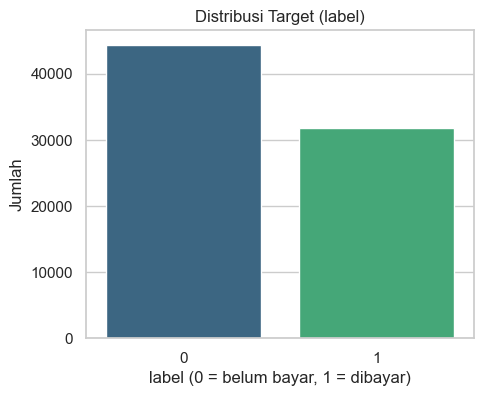

In [5]:
# Distribusi target (label): 1 = dibayar, 0 = belum dibayar
print(df["label"].value_counts())
print("\nProporsi:\n", df["label"].value_counts(normalize=True).round(3))

plt.figure(figsize=(5, 4))
sns.countplot(x="label", data=df, hue="label", palette="viridis", legend=False)
plt.title("Distribusi Target (label)")
plt.xlabel("label (0 = belum bayar, 1 = dibayar)")
plt.ylabel("Jumlah")
plt.show()


### 4.2 Nilai Hilang (Missing Values)
Melihat proporsi `NaN` per kolom untuk menentukan strategi imputasi (median untuk numerik, konstanta untuk kategorikal).

Kolom dengan missing value (proporsi):
rental_value          1.000
volume                1.000
npa                   0.998
advertisement_type    0.984
business_name         0.280
omzet                 0.119
fare                  0.101
dtype: float64


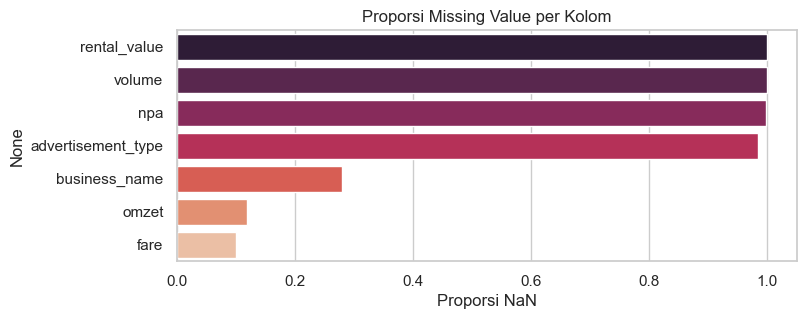

In [6]:
# Persentase nilai hilang (missing) per kolom
missing = df.isna().mean().sort_values(ascending=False)
missing_nonzero = missing[missing > 0]
print("Kolom dengan missing value (proporsi):")
print(missing_nonzero.round(3))

if not missing_nonzero.empty:
    plt.figure(figsize=(8, max(3, 0.4 * len(missing_nonzero))))
    sns.barplot(x=missing_nonzero.values, y=missing_nonzero.index,
                hue=missing_nonzero.index, palette="rocket", legend=False)
    plt.title("Proporsi Missing Value per Kolom")
    plt.xlabel("Proporsi NaN")
    plt.show()


### 4.3 Distribusi per Kategori Utama
Jumlah baris pada jenis pajak (`tax_name`), kecamatan (`district_name`), dan tahun (`collection_year`) yang paling dominan.

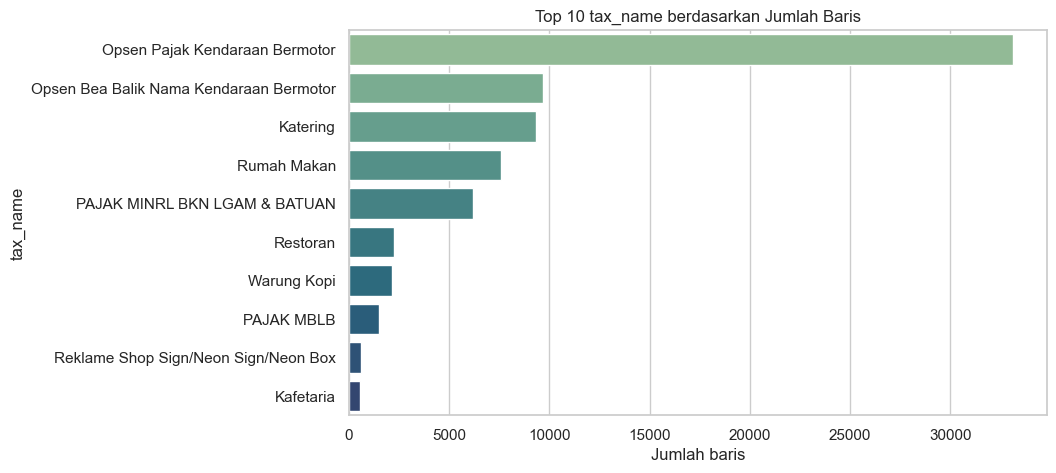

In [7]:
# Top 10 jenis pajak (tax_name) berdasarkan jumlah baris
top_tax = df["tax_name"].value_counts().head(10)

plt.figure(figsize=(9, 5))
sns.barplot(x=top_tax.values, y=top_tax.index,
            hue=top_tax.index, palette="crest", legend=False)
plt.title("Top 10 tax_name berdasarkan Jumlah Baris")
plt.xlabel("Jumlah baris")
plt.ylabel("tax_name")
plt.show()


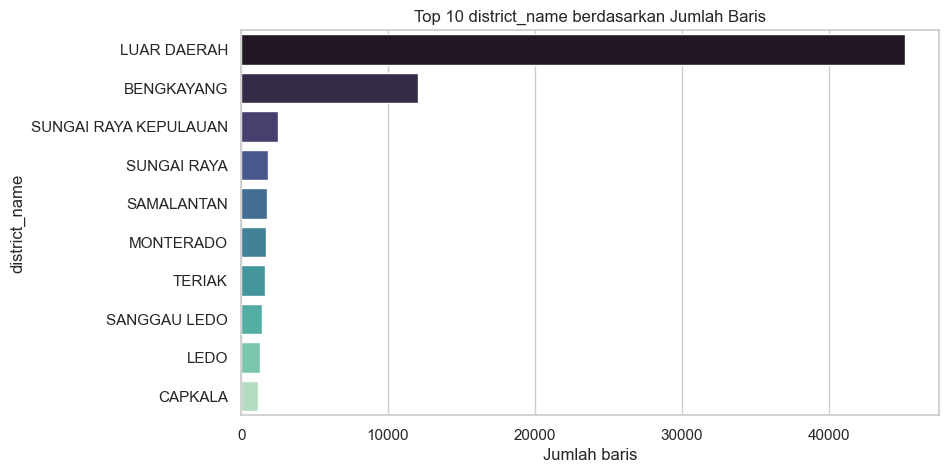

In [8]:
# Top 10 kecamatan (district_name) berdasarkan jumlah baris
top_dist = df["district_name"].value_counts().head(10)

plt.figure(figsize=(9, 5))
sns.barplot(x=top_dist.values, y=top_dist.index,
            hue=top_dist.index, palette="mako", legend=False)
plt.title("Top 10 district_name berdasarkan Jumlah Baris")
plt.xlabel("Jumlah baris")
plt.ylabel("district_name")
plt.show()


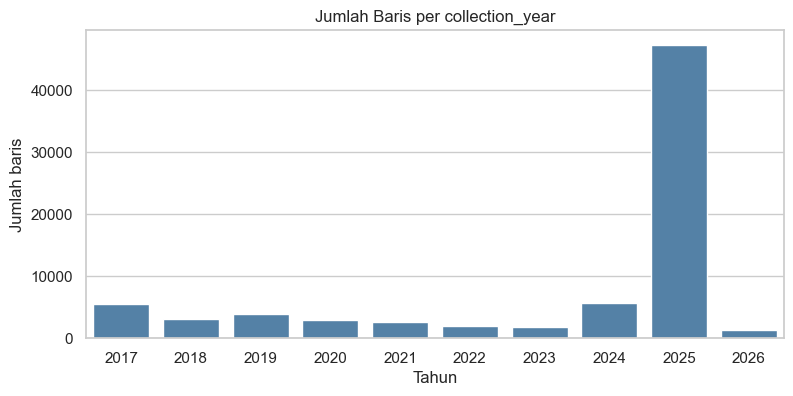

In [9]:
# Distribusi jumlah baris per tahun penagihan (collection_year)
year_counts = df["collection_year"].dropna().astype(int).value_counts().sort_index()

plt.figure(figsize=(9, 4))
sns.barplot(x=year_counts.index.astype(str), y=year_counts.values,
            color="steelblue")
plt.title("Jumlah Baris per collection_year")
plt.xlabel("Tahun")
plt.ylabel("Jumlah baris")
plt.show()


### 4.4 Korelasi Fitur Numerik
Heatmap korelasi membantu mendeteksi fitur yang saling berkorelasi kuat (potensi redundansi).

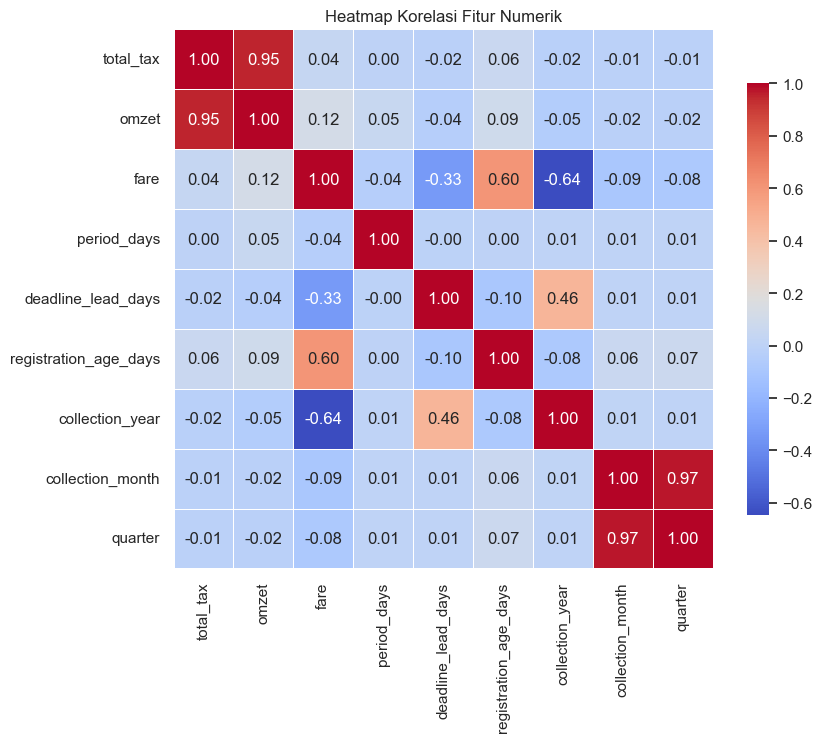

In [10]:
# Korelasi antar fitur NUMERIC (coerce ke numeric agar aman)
num_df = df[NUMERIC].apply(pd.to_numeric, errors="coerce")
corr = num_df.corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Heatmap Korelasi Fitur Numerik")
plt.show()


### 4.5 total_tax vs label
Boxplot membandingkan sebaran nominal pajak antara tagihan yang dibayar dan yang belum. Skala log dipakai karena distribusi sangat menceng ke kanan.

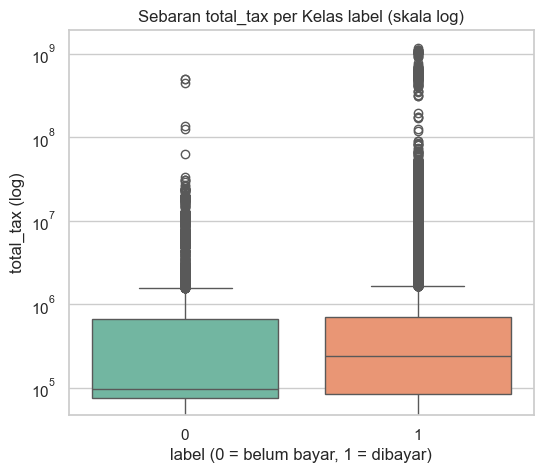

In [11]:
# Boxplot total_tax terhadap label.
# total_tax sangat right-skewed, gunakan sumbu-y log agar sebaran terbaca.
plt.figure(figsize=(6, 5))
sns.boxplot(x="label", y="total_tax", data=df,
            hue="label", palette="Set2", legend=False)
plt.yscale("log")
plt.title("Sebaran total_tax per Kelas label (skala log)")
plt.xlabel("label (0 = belum bayar, 1 = dibayar)")
plt.ylabel("total_tax (log)")
plt.show()


## 5. Data Preprocessing

Terapkan pembersihan sesuai kontrak, split stratified, lalu fit `ColumnTransformer` (imputasi + scaling numerik, imputasi + one-hot encoding kategorikal). Preprocessor di-fit **hanya** pada data train untuk menghindari kebocoran data.

### 5.1 Pembersihan Data (sesuai kontrak)

In [12]:
# --- Pembersihan sesuai KONTRAK ---
data = df.copy()

# 1) Buang kolom yang tidak dipakai
data = data.drop(columns=[c for c in DROP_COLS if c in data.columns], errors="ignore")

# 2) Kolom kategorikal -> string + isi NaN
#    advertisement_type -> "NONE"; sisanya -> "UNKNOWN"
for col in CATEGORICAL:
    fill_value = "NONE" if col == "advertisement_type" else "UNKNOWN"
    data[col] = data[col].astype("string").fillna(fill_value).astype(str)

# 3) Kolom numerik -> pastikan numeric (NaN diimputasi oleh pipeline nanti)
for col in NUMERIC:
    data[col] = pd.to_numeric(data[col], errors="coerce")

print("Bentuk akhir setelah clean:", data.shape)
data.head()


Bentuk akhir setelah clean: (76205, 16)


,label,tax_code,tax_name,advertisement_type,total_tax,omzet,fare,collection_year,collection_month,quarter,period_days,deadline_lead_days,registration_age_days,upt,district_name,business_name
0,1,1101,Motel,NONE,1105000.0,11050000.0,10.0,2017,3.0,1.0,27,8,111,f,BENGKAYANG,UNKNOWN
1,1,1104,Reklame Mini Billboard (ukuran s/d 6m2),1.0,1875000.0,NaN,25.0,2017,6.0,2.0,373,15,132,f,LUAR DAERAH,PT
2,1,1111,PAJAK MINRL BKN LGAM & BATUAN,NONE,28350.0,NaN,NaN,2017,6.0,2.0,-276,-97,1,f,SELUAS,UNKNOWN
3,1,1101,Hotel Melati Satu,NONE,5815000.0,58150000.0,10.0,2017,2.0,1.0,30,5,40,f,BENGKAYANG,CV
4,1,1101,Hotel Melati Satu,NONE,7197100.0,71971000.0,10.0,2017,3.0,1.0,27,7,66,f,BENGKAYANG,CV


### 5.2 Split Train/Test (stratified)

In [13]:
# Pisahkan fitur (mentah) & target, lalu split stratified
feature_cols = NUMERIC + CATEGORICAL
X = data[feature_cols]
y = data[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train:", X_train.shape, "| Test:", X_test.shape)


Train: (60964, 15) | Test: (15241, 15)


### 5.3 Fit ColumnTransformer & Jumlah Fitur OHE

In [14]:
# --- Bangun ColumnTransformer sesuai KONTRAK ---
preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imp", SimpleImputer(strategy="median")),
        ("sc", StandardScaler()),
    ]), NUMERIC),
    ("cat", Pipeline([
        ("imp", SimpleImputer(strategy="constant", fill_value="UNKNOWN")),
        ("ohe", OneHotEncoder(handle_unknown="ignore")),
    ]), CATEGORICAL),
])

# Fit HANYA pada data train
X_train_enc = preprocessor.fit_transform(X_train)
print("Jumlah fitur setelah OHE:", X_train_enc.shape[1])


Jumlah fitur setelah OHE: 99


### 5.4 (Opsional) Simpan Artefak
Demonstrasi penyimpanan `train.csv`, `test.csv`, dan `preprocessor.joblib` ke folder `pajak_daerah_preprocessing/`.

In [15]:
# (Opsional / demonstrasi) Simpan train/test mentah + preprocessor ke folder
import os
import joblib

out_dir = "pajak_daerah_preprocessing"
os.makedirs(out_dir, exist_ok=True)

train_df = X_train.copy(); train_df[TARGET] = y_train.values
test_df = X_test.copy();  test_df[TARGET] = y_test.values
train_df.to_csv(os.path.join(out_dir, "train.csv"), index=False)
test_df.to_csv(os.path.join(out_dir, "test.csv"), index=False)
joblib.dump(preprocessor, os.path.join(out_dir, "preprocessor.joblib"))

print("Artefak tersimpan di folder:", out_dir)
print(os.listdir(out_dir))


Artefak tersimpan di folder: pajak_daerah_preprocessing
['preprocessor.joblib', 'test.csv', 'train.csv']
